# 14. VAE 与扩散模型（🟡 高频 · 生成三巨头之二/三）

> 承接 08/13 篇。GAN 是**隐式**学分布（对抗博弈）；VAE 走**显式似然下界**；
> 扩散模型（DDPM）则是**逐步去噪**——当前图像生成的 SOTA 路线。
>
> 本节把两者的数学讲透并用 torch 在同一个 8 高斯环 toy 上跑通：VAE（ELBO + 重参数化）、
> DDPM（前向加噪 + 反向去噪采样）。


## 核心概念

### (a) 🗂️ VAE 与扩散模型知识结构

这篇文章讲生成三巨头之二/三：VAE 走显式似然下界 ELBO，扩散模型 DDPM 走逐步去噪，两者都在同一个 8 高斯环 toy 上跑通。

```mermaid
flowchart TB
    Node1["🧠 生成模型的目标"]
    Node1 --> Node2["😵 边缘似然积分不可解"]
    Node2 --> Node3["📐 ELBO 证据下界"]
    Node3 --> Node4["🎲 重参数化技巧"]
    Node4 --> Node5["🧪 toy VAE 训练"]
    Node1 --> Node6["❄️ DDPM 前向加噪"]
    Node6 --> Node7["🔥 DDPM 反向去噪"]
    Node7 --> Node8["🔮 预测噪声的训练目标"]
    Node8 --> Node9["⚖️ GAN/VAE/扩散三巨头对比"]
```

- **生成模型的目标**：想让模型学会数据分布 p(x)，这样就能采样出新样本。VAE 和扩散模型是两种不同的"打开方式"：一个最大化似然下界，一个学去噪。
- **边缘似然积分不可解**：log p(x) = log ∫p(x|z)p(z)dz 的积分没有解析解——直接最大化做不了，这是生成建模的核心困难。
- **ELBO 证据下界**：引入变分后验 q(z|x)，log p(x) ≥ E_q[log p(x|z)] - KL(q(z|x)‖p(z))，最大化这个下界代替直接最大化似然——"最大化一个够得着的下界"。
- **重参数化技巧**：从 q(z|x) 采样要把随机性"挪到"外部噪声上：z = μ + σ·ε，ε~N(0,1)。否则采样操作不可导，梯度没法流回编码器。
- **toy VAE 训练**：在 8 高斯环上训练 VAE，验证它学会的是"显式分布"—重构 + 采样都能跑通，和 GAN 的隐式分布形成对照。
- **DDPM 前向加噪**：固定不学习的扩散过程 q，逐步往干净图像上加高斯噪声，一步到位公式 x_t = √ᾱ_t x_0 + √(1-ᾱ_t)ε，加噪越深图像越接近纯噪声。
- **DDPM 反向去噪**：学一个网络从噪声里一步步"退"回干净图像 p_θ(x_{t-1}|x_t)，采样就是 T 步迭代去噪——当前图像生成 SOTA 的路线。
- **预测噪声的训练目标**：训练目标等价于 L_simple = E[‖ε - ε_θ(x_t, t)‖²]，即网络预测的噪声和真噪声的 MSE。不直接学像素，而是学"这步加了多少噪声"。
- **GAN/VAE/扩散三巨头对比**：GAN 隐式博弈训练最不稳、一步采样快；VAE 似然下界训练稳、采样快但图像偏糊；扩散训练最稳、质量最高但采样要 T 步迭代（慢）。

> 🕸️ **网络配图**（Wikimedia Commons）
>
> ![14 VAE与扩散模型 1](images/web_14_VAE与扩散模型_1.jpg)
>
> 📷 来源：Wikimedia Commons · <a href="//commons.wikimedia.org/wiki/File:Reparameterized_Variation…

## 1. VAE：最大化似然的下界（白板推导）

生成模型想最大化 log p(x)，但 `p(x) = ∫ p(x|z)p(z) dz` 积分不可解 → 引入变分后验 q(z|x)：

```
log p(x) = E_{q}[log p(x)]                         （与 z 无关）
         ≥ E_{q}[log p(x|z)] − KL(q(z|x) ‖ p(z))   ← ELBO（证据下界）
```

- **第一项（重构项）**：解码器把 z 还原成 x 的对数似然 → 逼重构像
- **第二项（KL 项）**：q(z|x) 别离先验 p(z)=N(0,I) 太远 → 正则化 latent 空间
- 训练 = 最大化 ELBO（等价于最小化 `−重构 + KL`）

**重参数化技巧**：采样 z ~ N(μ, σ²) 不可导 → 写成 `z = μ + σ⊙ε, ε~N(0,I)` → 梯度穿过 μ/σ

> 面试金句：VAE 的 latent 是**有结构的**（连续、可插值），但生成质量偏糊
> （高斯假设 + 像素级重构损失太弱）→ 后来改进（β-VAE/VQ-VAE/dVAE）都是补这两点。



## 1.1 VAE：最大化似然的下界（白板推导）

### 目标：最大化 log p(x)，但边缘似然不可直接积分

- `log p(x) = log ∫ p(x|z)·p(z) dz`：z 连续高维 → 无闭式解 → 用**变分下界（ELBO）**替代。

### ELBO 推导（证据下界）

- 引入变分后验 q_φ(z|x)，对任意 q 恒有：
  `log p(x) = KL(q_φ(z|x) ‖ p_θ(z|x)) + ELBO`
- 第一项 KL ≥ 0（后验与真实后验的距离）→
  `log p(x) ≥ ELBO = E_{z~q}[log p_θ(x|z)] − KL(q_φ(z|x) ‖ p(z))`
- **两项含义**：重建似然（x 能否被 z 还原）+ 正则项（后验别偏离先验 N(0,I) 太远）。

### 重参数化技巧（让采样可反向传播）

- 直接从 q_φ(z|x) 采样，梯度无法穿过随机节点；
- 改写为 `z = μ_φ(x) + σ_φ(x) ⊙ ε`，`ε ~ N(0, I)` → 随机性转移到 ε，μ/σ 均可求梯度（实验 1 使用）。

### 高斯情形的闭式 KL

- 先验 p(z)=N(0,I)，后验 q=N(μ, diag(σ²))：
  `KL = ½ Σ_{d=1..D} (μ_d² + σ_d² − log σ_d² − 1)`
- 直观：μ→0、σ→1 时 KL→0（后验退回先验）。

### 解码器假设

- 二值图像：伯努利解码 `log p_θ(x|z) = Σ x·log x̂ + (1−x)·log(1−x̂)`（BCE）；
- 连续图像：高斯解码 → 重建项退化为 MSE。



## 1.2 扩散模型 DDPM（白板推导）

### 前向过程（加噪，固定、无参数）

- 单步：`q(x_t | x_{t−1}) = N(x_t; √(1−β_t)·x_{t−1}, β_t·I)`
- **任意步闭式**（重参数化累积）：`q(x_t | x_0) = N(x_t; √ᾱ_t·x_0, (1−ᾱ_t)·I)`，`ᾱ_t = Π_{s=1..t}(1−β_s)`
- 采样形式：`x_t = √ᾱ_t·x_0 + √(1−ᾱ_t)·ε`，`ε~N(0,I)` → 训练时**不需要逐步模拟加噪**。

### 反向过程（去噪，学习）

- 学习 `p_θ(x_{t−1} | x_t) = N(x_{t−1}; μ_θ(x_t, t), Σ_t·I)`。
- 由贝叶斯定理 + 前向闭式可求**真实后验** `q(x_{t−1} | x_t, x_0)` 的均值：
  `μ̃_t = (1/√ᾱ_t)·(x_t − (β_t/√(1−ᾱ_t))·ε)`（给定真实 ε 时）。
- **训练目标**（重参数化后等价于预测噪声）：
  `L_simple = E_{t, x_0, ε}[ ‖ε − ε_θ(x_t, t)‖² ]`
- **采样**（反向逐步去噪）：
  `x_{t−1} = (1/√(1−β_t))·(x_t − (β_t/√(1−ᾱ_t))·ε_θ(x_t, t)) + σ_t·z`（t>1 时加噪声 z）

### 关键超参表

- β_t 从 1e-4 **线性**升到 0.02（T=1000）；ᾱ_t 单调递减至 ≈0 → x_T 接近纯高斯噪声；
- 噪声预测网络 ε_θ 常用 U-Net（时间 t 通过正弦嵌入注入）。


In [ ]:
# ---- matplotlib 中文字体（防图内中文乱码）----
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Songti SC', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
# -------------------------------------------

# ---------- 关键组件：VAE 重参数化/高斯 KL + DDPM ᾱ 表/前向加噪/一步去噪 ----------
import torch, torch.nn.functional as F

def gaussian_kl(mu, logvar):
    # KL = ½ Σ (μ² + σ² − log σ² − 1)
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=-1)

def reparameterize(mu, logvar):
    # z = μ + σ ⊙ ε，ε~N(0,I)：随机性走 ε，μ/σ 可求梯度
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + std * eps

mu = torch.tensor([[0.3, -0.2], [0.1, 0.5]])
logvar = torch.tensor([[-0.2, 0.1], [0.3, -0.4]])
print('高斯 KL(q‖p) =', gaussian_kl(mu, logvar).tolist())
z = reparameterize(mu, logvar)
print('重参数化 z 形状 =', tuple(z.shape), '（与 μ 同形，含随机性）')

# ---- DDPM：ᾱ 表 与 前向/反向单步 ----
def ddpm_schedule(T=1000):
    beta = torch.linspace(1e-4, 0.02, T)
    alpha = 1.0 - beta
    alpha_bar = torch.cumprod(alpha, dim=0)
    return beta, alpha_bar

T = 1000
beta, abar = ddpm_schedule(T)
print('DDPM: ᾱ_1 = %.4f, ᾱ_500 = %.4f, ᾱ_1000 = %.4f（→0 接近纯噪声）' %
      (abar[0].item(), abar[499].item(), abar[-1].item()))

torch.manual_seed(0)
x0 = torch.randn(2, 1, 8, 8)          # 假设的真实图像
t = torch.randint(0, T, (2,))          # 随机时刻
eps = torch.randn_like(x0)
at = abar[t].view(-1, 1, 1, 1)
xt = torch.sqrt(at) * x0 + torch.sqrt(1 - at) * eps   # 前向一步闭式
print('前向加噪: t=%s, 噪声幅度 √(1−ᾱ)=%.3f' %
      (t.tolist(), torch.sqrt(1 - at).mean().item()))

# 反向一步：给定预测的 ε̂=eps，恢复 x0 的估计
x0_hat = (xt - torch.sqrt(1 - at) * eps) / torch.sqrt(at)
print('反向一步: ‖x0̂ − x0‖ 最大误差 =', (x0_hat - x0).abs().max().item())
print('✓ VAE 重参数化/KL 与 DDPM 调度/加噪/去噪验证通过')


ep    0  recon=12.4830  kl=0.0928


ep  600  recon=0.0148  kl=9.1650


ep 1200  recon=0.0153  kl=7.2832


ep 1800  recon=0.0144  kl=7.0098


ep 2400  recon=0.0122  kl=6.9983


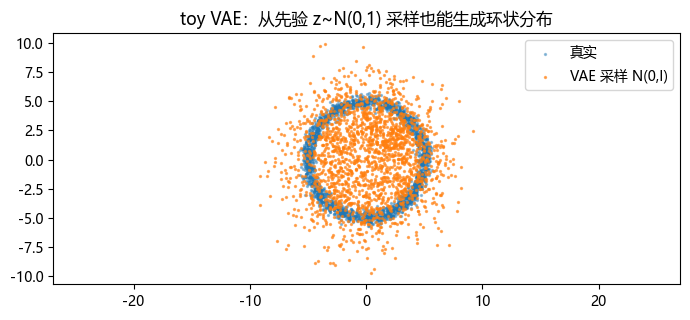

In [1]:
# ---------- 实验 1：toy VAE 在 8 高斯环上训练 ----------
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(0)
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

R, NS = 5.0, 8
rng = np.random.default_rng(0)
def sample_real(n):
    ang = rng.uniform(0, 2 * np.pi, n)
    r = R + rng.normal(0, 0.3, n)
    return torch.from_numpy(np.stack([r * np.cos(ang), r * np.sin(ang)], 1).astype('float32'))

class VAE(nn.Module):
    def __init__(self, d=2, h=32, z=2):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d, h), nn.ReLU(), nn.Linear(h, h), nn.ReLU())
        self.mu = nn.Linear(h, z); self.logvar = nn.Linear(h, z)
        self.dec = nn.Sequential(nn.Linear(z, h), nn.ReLU(), nn.Linear(h, h), nn.ReLU(), nn.Linear(h, d))
    def forward(self, x):
        e = self.enc(x)
        mu, lv = self.mu(e), self.logvar(e)
        z = mu + torch.exp(0.5 * lv) * torch.randn_like(mu)      # 重参数化
        return self.dec(z), mu, lv

model = VAE()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
for ep in range(3000):
    xb = sample_real(256)
    rec, mu, lv = model(xb)
    recon = F.mse_loss(rec, xb)                                  # 重构项（高斯似然简化）
    kl = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp(), dim=1).mean()
    loss = recon + 0.01 * kl                                     # 小 β：保住环结构
    opt.zero_grad(); loss.backward(); opt.step()
    if ep % 600 == 0:
        print('ep %4d  recon=%.4f  kl=%.4f' % (ep, recon.item(), kl.item()))

with torch.no_grad():
    z = torch.randn(2000, 2)
    samples = model.dec(z).numpy()
    real = sample_real(2000).numpy()
plt.figure(figsize=(7, 3.3))
plt.scatter(real[:, 0], real[:, 1], s=2, label='真实', alpha=0.4)
plt.scatter(samples[:, 0], samples[:, 1], s=2, label='VAE 采样 N(0,I)', alpha=0.6)
plt.legend(); plt.title('toy VAE：从先验 z~N(0,1) 采样也能生成环状分布')
plt.axis('equal'); plt.tight_layout(); plt.show()


## 2. 扩散模型 DDPM（白板推导）

**前向（加噪，固定）**：
`q(x_t | x_{t-1}) = N(x_t; √(1−β_t) x_{t-1}, β_t I)`
一步到位（重参数化 + 累积）：`x_t = √ᾱ_t x_0 + √(1−ᾱ_t) ε, ε~N(0,I)`，其中 `ᾱ_t = Π_{i≤t}(1−β_i)`

**反向（去噪，学习）**：学 `p_θ(x_{t-1}|x_t) = N(x_{t-1}; μ_θ(x_t,t), Σ_θ)`，训练目标等价于：

`L_simple(θ) = E_{t, x_0, ε}[ ‖ ε − ε_θ(√ᾱ_t x_0 + √(1−ᾱ_t) ε, t) ‖² ]`

即：**随机加噪 → 让网络预测噪声 ε**（不是直接预测 x！）。

**采样**：从 x_T ~ N(0,I) 开始，迭代去噪 T 步回到 x_0。

> 面试三连问：① 为什么预测噪声而不是 x？（训练/采样都更稳，重参数化后的简单形式）
> ② 训练时要时间 t 条件吗？（要：不同 t 噪声强度不同，网络要区分）
> ③ 和 GAN 比？（扩散更稳、覆盖全，但采样慢——T 步迭代）


In [2]:
# ---------- 实验 2：前向加噪可视化（同一个点被逐步“融化”） ----------
def forward_diffuse(x0, t, alphas_cum):
    # x0: (N,2), t: 标量
    sqrt_ac = alphas_cum[t] ** 0.5
    sqrt_1ac = (1 - alphas_cum[t]) ** 0.5
    return sqrt_ac * x0 + sqrt_1ac * torch.randn_like(x0)

T = 50
betas = torch.linspace(1e-4, 0.02, T)
alphas_cum = torch.cumprod(1 - betas, 0)
x0 = torch.tensor([[5.0, 0.0]])
for t in [0, 5, 15, 30, 49]:
    xt = forward_diffuse(x0, t, alphas_cum)
    print('t=%2d  噪声强度 √(1−ᾱ)=%.3f   x_t=(%+.2f, %+.2f)' %
          (t, (1 - alphas_cum[t]) ** 0.5, xt[0, 0].item(), xt[0, 1].item()))
print('→ 越往后信号越弱、噪声越强；到 t=T 近似各向同性高斯')


t= 0  噪声强度 √(1−ᾱ)=0.010   x_t=(+5.01, +0.00)
t= 5  噪声强度 √(1−ᾱ)=0.082   x_t=(+4.94, -0.06)
t=15  噪声强度 √(1−ᾱ)=0.222   x_t=(+5.06, +0.26)
t=30  噪声强度 √(1−ᾱ)=0.419   x_t=(+4.31, +0.99)
t=49  噪声强度 √(1−ᾱ)=0.630   x_t=(+3.75, -0.86)
→ 越往后信号越弱、噪声越强；到 t=T 近似各向同性高斯


ep    0  loss=1.0302


ep  600  loss=0.7739


ep 1200  loss=0.8056


ep 1800  loss=0.7899


ep 2400  loss=0.8332


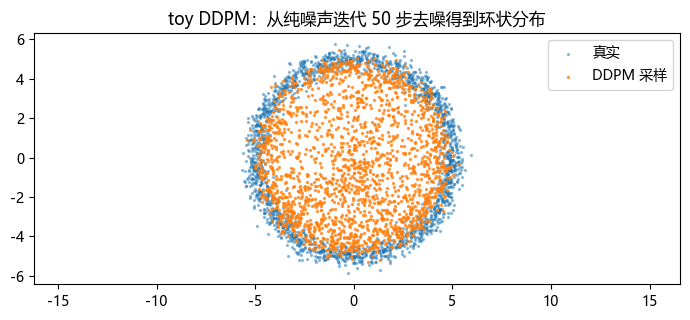

In [3]:
# ---------- 实验 3：toy DDPM 训练（预测噪声）+ 反向采样 ----------
T = 50
betas = torch.linspace(1e-4, 0.02, T)
alphas = 1 - betas
alphas_cum = torch.cumprod(alphas, 0)

# 简化“UNet”：ε_θ(x, t) = 2D 输入 + 时间特征 → MLP
class NoiseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.temb = nn.Linear(1, 16)
        self.net = nn.Sequential(nn.Linear(2 + 16, 64), nn.ReLU(),
                                 nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 2))
    def forward(self, x, t):
        tb = torch.sin(t.float().unsqueeze(-1) * torch.linspace(1, 10, 16))
        return self.net(torch.cat([x, tb], -1))

torch.manual_seed(0)
model = NoiseNet()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
for ep in range(3000):
    x0b = sample_real(256)
    t = rng.integers(0, T, 256)
    eps = torch.randn_like(x0b)
    ac = alphas_cum[t].unsqueeze(-1)
    xt = ac.sqrt() * x0b + (1 - ac).sqrt() * eps
    pred = model(xt, torch.from_numpy(t))
    loss = F.mse_loss(pred, eps)
    opt.zero_grad(); loss.backward(); opt.step()
    if ep % 600 == 0:
        print('ep %4d  loss=%.4f' % (ep, loss.item()))

# 反向采样：x_T ~ N(0,I) → 逐步去噪
@torch.no_grad()
def sample(n=2000):
    x = torch.randn(n, 2)
    for t in range(T - 1, -1, -1):
        eps_pred = model(x, torch.full((n,), t))
        if t > 0:
            x = (x - betas[t] / (1 - alphas_cum[t]).sqrt() * eps_pred) / alphas[t].sqrt() \
                + betas[t].sqrt() * torch.randn_like(x)
        else:
            x = (x - betas[t] / (1 - alphas_cum[t]).sqrt() * eps_pred) / alphas[t].sqrt()
    return x

samples = sample()
real = sample_real(2000).numpy()
plt.figure(figsize=(7, 3.3))
plt.scatter(real[:, 0], real[:, 1], s=2, label='真实', alpha=0.4)
plt.scatter(samples.numpy()[:, 0], samples.numpy()[:, 1], s=2, label='DDPM 采样', alpha=0.7)
plt.legend(); plt.title('toy DDPM：从纯噪声迭代 50 步去噪得到环状分布')
plt.axis('equal'); plt.tight_layout(); plt.show()


## 3. 三巨头对比表

| 维度 | GAN | VAE | 扩散 |
|------|-----|-----|------|
| 学什么 | 隐式分布（博弈） | 似然下界 ELBO | 逐步去噪（预测噪声） |
| 训练稳定 | 难（平衡/坍缩） | 稳 | 很稳 |
| 采样速度 | 一步（快） | 一步（快） | T 步迭代（慢） |
| 覆盖多样性 | 易坍缩 | 好 | 好 |
| 质量（图） | 高 | 糊 | 最高（SOTA） |

> 现实：文本→自回归；图像→扩散为主、GAN 在速度场景、VAE 在表示学习（latent 空间）。

## 4. 自测清单

- [ ] 能写出 ELBO 两项（重构 + KL）并解释各自作用
- [ ] 能讲清重参数化 z = μ + σ⊙ε 的必要性
- [ ] 能写 DDPM 前向公式 x_t = √ᾱ x_0 + √(1−ᾱ) ε 与训练目标 ‖ε − ε_θ‖²
- [ ] 能描述反向采样流程（x_T 噪声 → 去噪 T 步）
- [ ] 能画出 GAN/VAE/扩散三行对比表并给出选型观点

## 🎤 面试速答（背诵骨架）

- **VAE**：ELBO = E[log p(x|z)] − KL(q‖p)；重参数化使采样可导；latent 有结构但糊
- **DDPM 前向**：x_t = √ᾱ_t x_0 + √(1−ᾱ_t)ε；**训练**：预测噪声 ‖ε−ε_θ‖²；**采样**：T 步去噪
- **β 调度**：线性/余弦；时间 t 条件嵌入进网络
- **选型**：质量→扩散；速度→GAN；表示→VAE
